
Momentos de Hu:
[ 1.66659161e-01  2.81555750e-19  1.30272651e-10  1.39578119e-11
 -5.95185906e-22 -7.40627003e-21 -1.56747221e-30]

Momentos de Hu:
[ 1.59159128e-01  3.26991917e-10  5.66560220e-10  5.98015972e-15
  1.10075892e-26 -1.08138737e-19  0.00000000e+00]

Momentos de Hu:
[ 1.93541567e-01  4.28818652e-04  4.59574054e-03  1.17770265e-05
 -2.73956269e-09 -2.43862229e-07  4.15673650e-11]


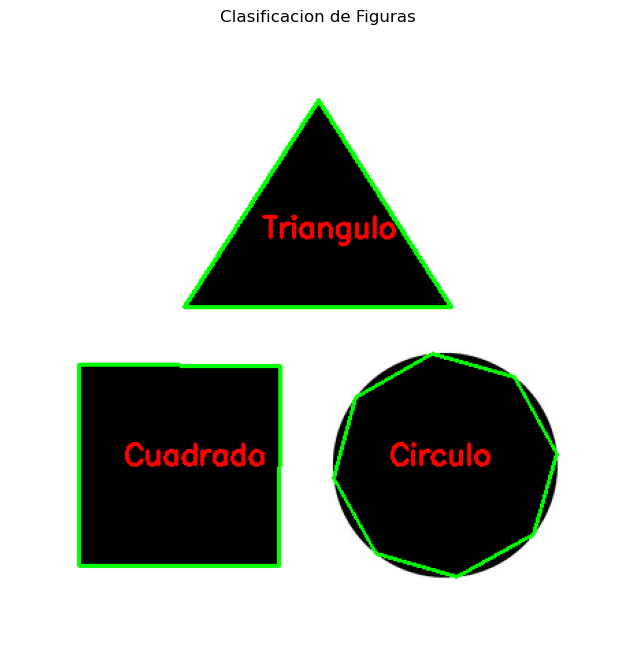

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("p1.jpg")

resultado = imagen.copy()

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

_, binaria = cv2.threshold(
    gris,
    127,
    255,
    cv2.THRESH_BINARY_INV
)

contornos, _ = cv2.findContours(
    binaria,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contorno in contornos:

    if cv2.contourArea(contorno) < 100:
        continue

    momentos = cv2.moments(contorno)
    hu = cv2.HuMoments(momentos)

    print("\nMomentos de Hu:")
    print(hu.flatten())

    perimetro = cv2.arcLength(contorno, True)

    aprox = cv2.approxPolyDP(
        contorno,
        0.04 * perimetro,
        True
    )

    vertices = len(aprox)

    if vertices == 3:
        figura = "Triangulo"
    elif vertices == 4:
        figura = "Cuadrado"
    else:
        figura = "Circulo"

    M = cv2.moments(contorno)

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    cv2.drawContours(resultado, [aprox], -1, (0, 255, 0), 2)

    cv2.putText(
        resultado,
        figura,
        (cx - 40, cy),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(resultado_rgb)
plt.title("Clasificacion de Figuras")
plt.axis("off")
plt.show()


Momentos de Hu:
[ 1.66659161e-01  2.81555750e-19  1.30272651e-10  1.39578119e-11
 -5.95185906e-22 -7.40627003e-21 -1.56747221e-30]

Momentos de Hu:
[ 1.59159128e-01  3.26991917e-10  5.66560220e-10  5.98015972e-15
  1.10075892e-26 -1.08138737e-19  0.00000000e+00]

Momentos de Hu:
[ 1.93541567e-01  4.28818652e-04  4.59574054e-03  1.17770265e-05
 -2.73956269e-09 -2.43862229e-07  4.15673650e-11]


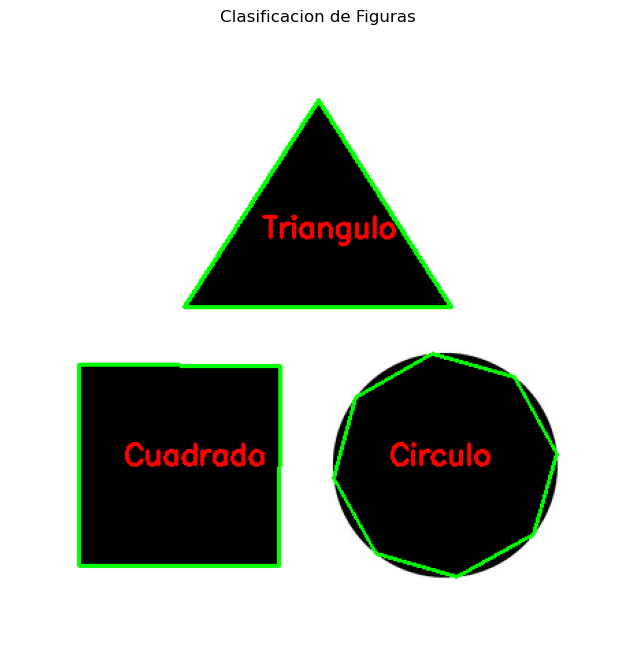

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("p1.jpg")

if imagen is None:
    print("No se pudo cargar la imagen.")
    exit()

resultado = imagen.copy()

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

_, binaria = cv2.threshold(
    gris,
    127,
    255,
    cv2.THRESH_BINARY_INV
)

contornos, _ = cv2.findContours(
    binaria,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contorno in contornos:

    if cv2.contourArea(contorno) < 100:
        continue

    momentos = cv2.moments(contorno)
    hu = cv2.HuMoments(momentos)

    print("\nMomentos de Hu:")
    print(hu.flatten())

    perimetro = cv2.arcLength(contorno, True)

    aprox = cv2.approxPolyDP(
        contorno,
        0.04 * perimetro,
        True
    )

    vertices = len(aprox)

    if vertices == 3:
        figura = "Triangulo"
    elif vertices == 4:
        figura = "Cuadrado"
    else:
        figura = "Circulo"

    if momentos["m00"] == 0:
        continue

    cx = int(momentos["m10"] / momentos["m00"])
    cy = int(momentos["m01"] / momentos["m00"])

    cv2.drawContours(
        resultado,
        [aprox],
        -1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        resultado,
        figura,
        (cx - 40, cy),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

resultado_rgb = cv2.cvtColor(
    resultado,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 8))
plt.imshow(resultado_rgb)
plt.title("Clasificacion de Figuras")
plt.axis("off")
plt.show()